In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

2026-04-23 22:11:59.642976: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


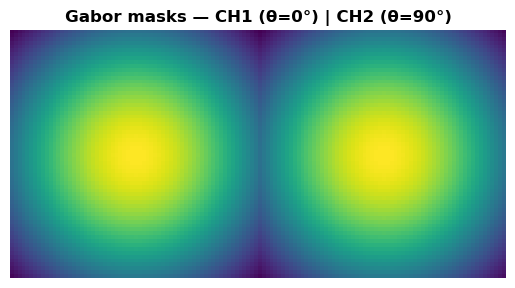

Encoding Gaussian speckles...


NameError: name 'datasets' is not defined

In [8]:
def myfft2(A):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))


def gabor_THIS(A, GM1, GM2):
    """
    Gabor encoder — direct replacement for Baurzhan's vort_THIS.

    Takes a batch of images and applies:
    1. Phase encode: exp(i * image * pi/2)  — same as Baurzhan
    2. Multiply by Lens
    3. FFT (myfft2)
    4. Multiply by Gabor mask in Fourier plane — replaces vortex mask
    5. Take magnitude
    6. Normalise to [-1, 1]
    7. Concatenate dual channel

    Can be applied to both:
    - Gaussian beam speckles (Method 1 training)
    - Real chest X-ray images (Method 2 training + inference)

    Parameters
    ----------
    A   : (N, H, W) float32 — batch of images in [0,1]
    GM1 : (H, W) float64   — Gabor Fourier mask channel 1
    GM2 : (H, W) float64   — Gabor Fourier mask channel 2

    Returns
    -------
    out : (N, H, W*2) float32 — dual channel Gabor encoded, normalised to [-1,1]
    """
    length = A.shape[0]
    out    = np.zeros((length, A.shape[1], A.shape[2] * 2), dtype=np.float32)

    for i in range(length):
        phase = np.exp(1j * A[i].astype(np.float64) * np.pi / 2)

        A1 = np.abs(myfft2(phase * Lens) * GM1).astype(np.float32)
        A2 = np.abs(myfft2(phase * Lens) * GM2).astype(np.float32)

        A1 = (A1 - np.amin(A1)) / (np.amax(A1 - np.amin(A1)) + 1e-8) * 2 - 1
        A2 = (A2 - np.amin(A2)) / (np.amax(A2 - np.amin(A2)) + 1e-8) * 2 - 1

        out[i] = np.hstack((A1, A2))

    return out


def make_gabor_mask(DIM=64, omega_0=0.07, theta=0, sigma_f=0.5):
    """
    Gabor mask in the Fourier plane.
    Gaussian blob centred at (omega_0, theta) — bandpass filter.

    Parameters
    ----------
    DIM     : int   — image dimension
    omega_0 : float — centre frequency in cycles/pixel
    theta   : float — orientation in radians
    sigma_f : float — bandwidth

    Returns
    -------
    mask : (DIM, DIM) float64 in [0,1]
    """
    freqs = np.fft.fftshift(np.fft.fftfreq(DIM))
    U, V  = np.meshgrid(freqs, freqs)

    u0 = omega_0 * np.cos(theta)
    v0 = omega_0 * np.sin(theta)

    mask_pos = np.exp(-((U - u0)**2 + (V - v0)**2) / (2 * sigma_f**2))
    mask_neg = np.exp(-((U + u0)**2 + (V + v0)**2) / (2 * sigma_f**2))

    mask = mask_pos + mask_neg
    mask = mask / mask.max()

    return mask.astype(np.float64)


# ── Coordinates + Lens — same as Baurzhan ─────────────────────────────────────
DIM     = 64
xmax    = 10
dx      = 2 * xmax / DIM

x       = np.linspace(-xmax, xmax - dx, DIM)
X, Y    = np.meshgrid(x, x)
R2      = X**2 + Y**2
T       = np.arctan2(Y, X)

flambda = 80
Lens    = np.exp(-1j * R2 / (flambda / 10))

# ── Gabor masks ───────────────────────────────────────────────────────────────
GM1 = make_gabor_mask(DIM, omega_0=0.07, theta=0,       sigma_f=0.5)
GM2 = make_gabor_mask(DIM, omega_0=0.07, theta=np.pi/2, sigma_f=0.5)

plt.imshow(np.hstack((GM1, GM2)), cmap='viridis')
plt.title('Gabor masks — CH1 (θ=0°) | CH2 (θ=90°)', fontweight='bold')
plt.axis('off')
plt.show()

# ── Encode Gaussian speckles — Method 1 ──────────────────────────────────────
# datasets shape: (10000, 128, 128) — single dist=4.0
print('Encoding Gaussian speckles...')
encoded_speckles = gabor_THIS(datasets, GM1, GM2)   # (10000, 128, 256)

print(f'Gaussian speckles shape  : {datasets.shape}')
print(f'Encoded speckles shape   : {encoded_speckles.shape}')
print(f'Encoded speckles range   : [{encoded_speckles.min():.3f}, '
      f'{encoded_speckles.max():.3f}]')

# ── Visual check ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(datasets[50],                      cmap='magma')
axes[0].set_title('Gaussian speckle\n(ground truth)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(encoded_speckles[50, :, :DIM],     cmap='magma')
axes[1].set_title('Gabor encoded CH1\n(input to model)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(encoded_speckles[50, :, DIM:],     cmap='magma')
axes[2].set_title('Gabor encoded CH2\n(input to model)', fontweight='bold')
axes[2].axis('off')

axes[3].imshow(encoded_speckles[50],               cmap='magma')
axes[3].set_title('Dual channel\n(full input)', fontweight='bold')
axes[3].axis('off')

plt.suptitle(f'Method 1 — Gaussian speckle (dist={dist}) → Gabor encoder',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from skimage.exposure import equalize_adapthist
from skimage.filters import gaussian as sk_gaussian
from tqdm import tqdm
import psutil
from scipy.ndimage import uniform_filter, gaussian_filter

DIM         = 64
NUM_CLASSES = 2

TRAIN_DIR = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train'
TEST_DIR  = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test'

# ── Load raw data ─────────────────────────────────────────────────────────────
def load_data(data_dir, dim=DIM):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int',
        image_size=(dim, dim),
        batch_size=None,
        shuffle=False
    )
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    return x, y

print('Loading training data...')
x_train_raw, y_train_int = load_data(TRAIN_DIR)
print('Loading test data...')
x_test_raw,  y_test_int  = load_data(TEST_DIR)

n_train, n_test = len(x_train_raw), len(x_test_raw)
print(f'Train: {n_train} | Test: {n_test}')

# Verify class order — Keras sorts alphabetically
class_names = sorted(os.listdir(TRAIN_DIR))
print(f'Class order: {class_names}')  # [NORMAL, PNEUMONIA] -> 0, 1

# ── Grayscale + normalise ─────────────────────────────────────────────────────
def to_gray_norm(images_rgb, N):
    out = np.empty((N, DIM, DIM), dtype=np.float32)
    for i in tqdm(range(N), desc='Grayscale+Norm'):
        gray   = cv2.cvtColor(images_rgb[i].astype(np.uint8),
                               cv2.COLOR_RGB2GRAY)
        out[i] = gray / 255.0
    return out

x_train_gray = to_gray_norm(x_train_raw, n_train)
x_test_gray  = to_gray_norm(x_test_raw,  n_test)
del x_train_raw, x_test_raw

# ── One-hot labels ────────────────────────────────────────────────────────────
y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_int,  num_classes=NUM_CLASSES)

# ── Preprocessing — CLAHE + central crop + smoothing (no segmentation) ────────
def preprocess_xray(img):
    """
    Input : (64, 64) float32 in [0,1] — grayscale, normalised
    Output: (64, 64) float32 in [0,1]
    Steps : CLAHE → fixed central crop → resize → Gaussian smooth → renorm
    """
    # 1. CLAHE
    img = equalize_adapthist(img, clip_limit=0.03).astype(np.float32)
    # 2. Fixed central crop — removes chest wall borders
    h, w  = img.shape
    pad_h = int(h * 0.10)
    pad_w = int(w * 0.08)
    img   = img[pad_h:h-pad_h, pad_w:w-pad_w]
    # 3. Resize back to 64x64
    img = cv2.resize(img, (DIM, DIM), interpolation=cv2.INTER_AREA)
    # 4. Gaussian smoothing
    img = sk_gaussian(img, sigma=0.5).astype(np.float32)
    # 5. Re-normalise
    if img.max() > 1e-8:
        img = img / img.max()
    return img

print('Preprocessing training images...')
x_train_normal = np.zeros((n_train, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_train), desc='Train'):
    x_train_normal[i] = preprocess_xray(x_train_gray[i])

print('Preprocessing test images...')
x_test_normal = np.zeros((n_test, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_test), desc='Test'):
    x_test_normal[i] = preprocess_xray(x_test_gray[i])

del x_train_gray, x_test_gray


def apply_smooth_region_filter(image, window=20):
    """
    Suppresses high-contrast edge regions (ribs) and preserves
    smooth regions (consolidation opacity).

    Parameters
    ----------
    image  : (H, W) float32 in [0,1]
    window : int — neighbourhood size (5-7 at 64×64, 9-11 at 128×128)

    Returns
    -------
    filtered : (H, W) float32 in [0,1] — edge-suppressed image
    """
    mean_sq   = uniform_filter(image**2, size=window)
    sq_mean   = uniform_filter(image,    size=window)**2
    local_std = np.sqrt(np.clip(mean_sq - sq_mean, 0, None)).astype(np.float32)

    # Smooth mask — inverse of normalised local std
    s_rng = local_std.max() - local_std.min()
    local_std_norm  = (local_std - local_std.min()) / (s_rng + 1e-8)
    smooth_mask     = gaussian_filter(1.0 - local_std_norm, sigma=1.0)

    # Apply and renormalise
    filtered = image * smooth_mask
    f_rng    = filtered.max() - filtered.min()
    filtered = (filtered - filtered.min()) / (f_rng + 1e-8)

    return filtered.astype(np.float32)


x_train = np.zeros((n_train, DIM, DIM), dtype=np.float32)
x_test = np.zeros((n_test, DIM, DIM), dtype=np.float32)

for i, img in enumerate(x_train_normal):
    x_train[i] = apply_smooth_region_filter(img)

for i, img in enumerate(x_test_normal):
    x_test[i] = apply_smooth_region_filter(img)

del x_train_normal, x_test_normal


# ── Verify class split ────────────────────────────────────────────────────────
N_NORMAL    = int(np.sum(y_train_int == 0))
N_PNEUMONIA = int(np.sum(y_train_int == 1))
print(f'\nNormal    : {N_NORMAL}  (idx 0 to {N_NORMAL-1})')
print(f'Pneumonia : {N_PNEUMONIA}  (idx {N_NORMAL} to {n_train-1})')
print(f'x_train   : {x_train.shape}')
print(f'x_test    : {x_test.shape}')

ram = psutil.virtual_memory()
print(f'RAM available: {ram.available/1e9:.1f} GB')


Loading training data...
Found 5216 files belonging to 2 classes.


I0000 00:00:1777007524.012263  134822 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-04-23 22:12:11.742479: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading test data...
Found 624 files belonging to 2 classes.


2026-04-23 22:12:18.489577: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-23 22:12:19.894901: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train: 5216 | Test: 624
Class order: ['NORMAL', 'PNEUMONIA']


...

Preprocessing training images...


Train: 100%|██████████| 5216/5216 [00:12<00:00, 410.34it/s]


Preprocessing test images...


Test: 100%|██████████| 624/624 [00:01<00:00, 395.91it/s]



Normal    : 1341  (idx 0 to 1340)
Pneumonia : 3875  (idx 1341 to 5215)
x_train   : (5216, 64, 64)
x_test    : (624, 64, 64)
RAM available: 12.2 GB


Normal    : (1341, 4096)
Pneumonia : (3875, 4096)
All       : (5216, 4096)

Variance explained by 50 PCs:
  Normal    : 84.8%
  Pneumonia : 90.0%
  All       : 89.0%


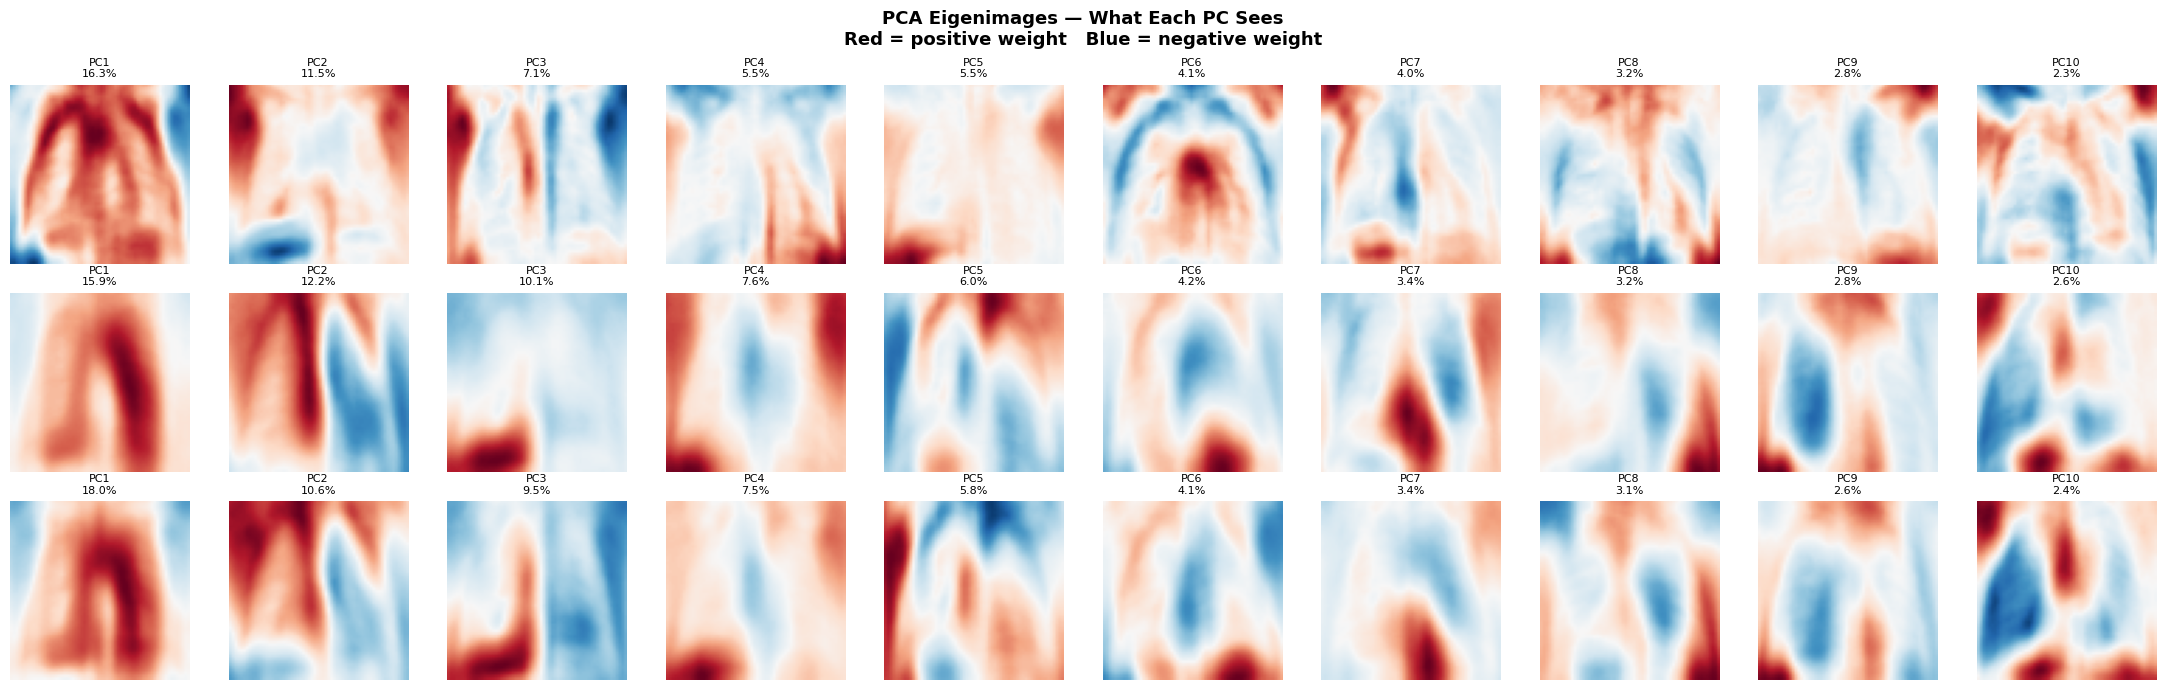

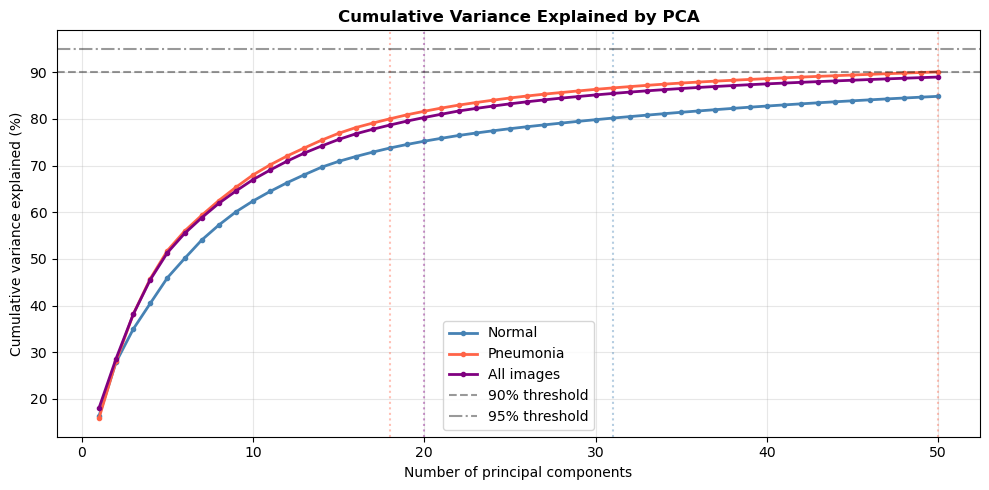

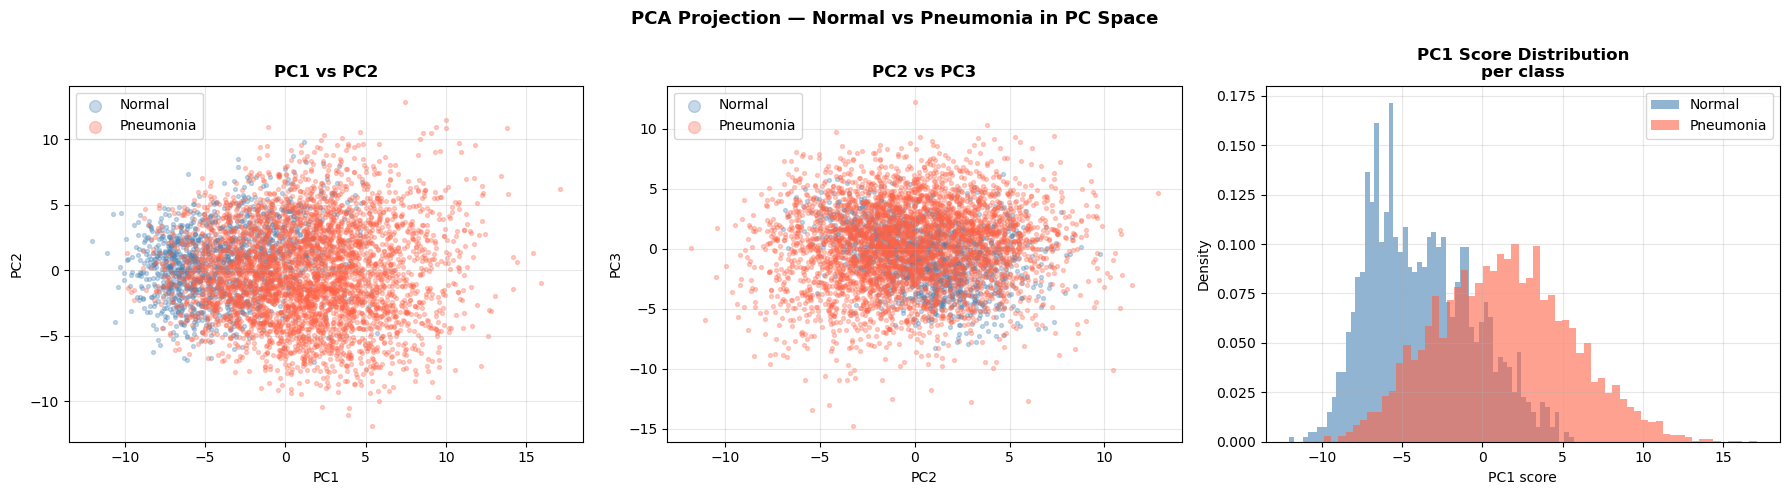

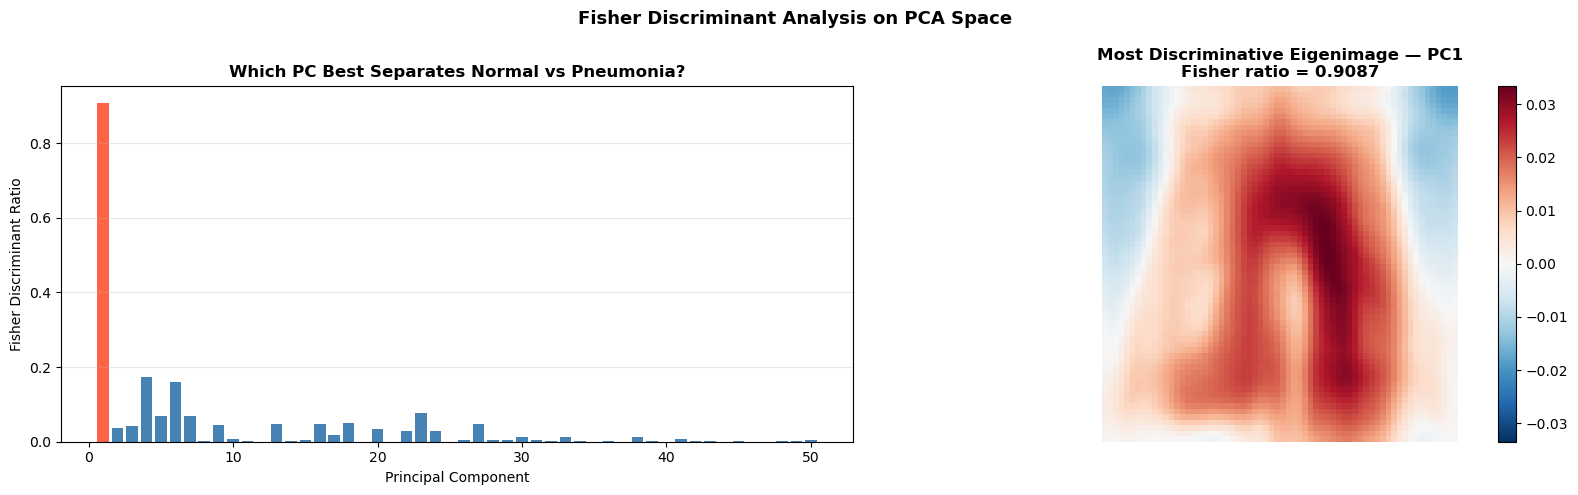

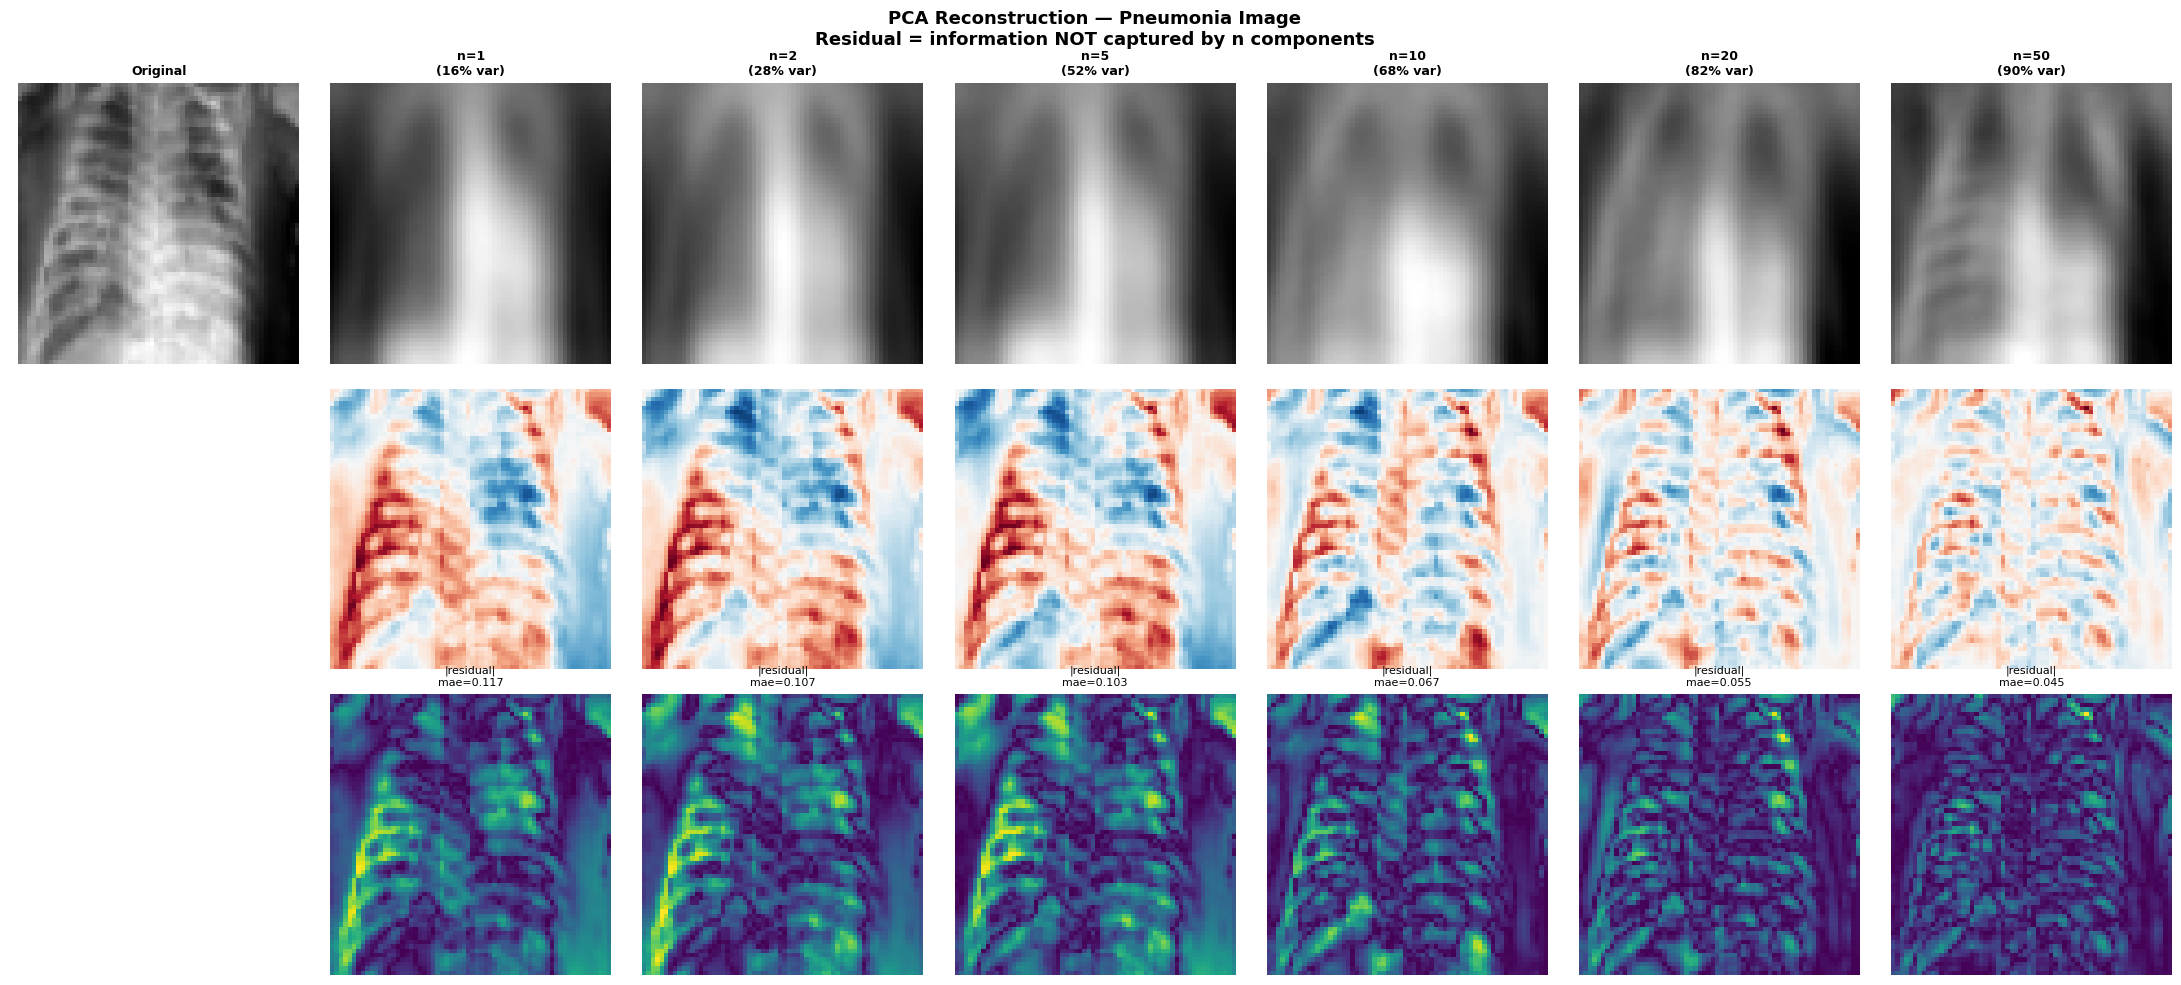


PCA SUMMARY

Components needed to explain:
  80% variance — Normal    :  31 components
  80% variance — Pneumonia :  18 components
  80% variance — All       :  20 components

  90% variance — Normal    :   1 components
  90% variance — Pneumonia :  50 components
  90% variance — All       :   1 components

  95% variance — Normal    :   1 components
  95% variance — Pneumonia :   1 components
  95% variance — All       :   1 components

  99% variance — Normal    :   1 components
  99% variance — Pneumonia :   1 components
  99% variance — All       :   1 components

Most discriminative PC : PC1
Fisher ratio           : 0.9087

Top 5 discriminative PCs:
  PC 1: Fisher=0.9087  Var=18.0%
  PC 4: Fisher=0.1726  Var=7.5%
  PC 6: Fisher=0.1599  Var=4.1%
  PC23: Fisher=0.0772  Var=0.5%
  PC 5: Fisher=0.0700  Var=5.8%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ── Data preparation ──────────────────────────────────────────────────────────
y_ints         = np.argmax(y_train, axis=1)
normal_imgs    = x_train[y_ints == 0]   # (1341, 64, 64)
pneumonia_imgs = x_train[y_ints == 1]   # (3875, 64, 64)
DIM            = 64

X_normal    = normal_imgs.reshape(len(normal_imgs), -1).astype(np.float32)
X_pneumonia = pneumonia_imgs.reshape(len(pneumonia_imgs), -1).astype(np.float32)
X_all       = x_train.reshape(len(x_train), -1).astype(np.float32)
y_all       = y_ints

print(f'Normal    : {X_normal.shape}')
print(f'Pneumonia : {X_pneumonia.shape}')
print(f'All       : {X_all.shape}')

# ── Fit PCA ───────────────────────────────────────────────────────────────────
n_components = 50

pca_normal    = PCA(n_components=n_components, random_state=42)
pca_pneumonia = PCA(n_components=n_components, random_state=42)
pca_all       = PCA(n_components=n_components, random_state=42)

pca_normal.fit(X_normal)
pca_pneumonia.fit(X_pneumonia)
pca_all.fit(X_all)

print(f'\nVariance explained by {n_components} PCs:')
print(f'  Normal    : {pca_normal.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  Pneumonia : {pca_pneumonia.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  All       : {pca_all.explained_variance_ratio_.sum()*100:.1f}%')

# ── Plot 1: Eigenimages — what each PC sees ───────────────────────────────────
n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(22, 7))

for col in range(n_show):
    for row, (pca, label) in enumerate([
        (pca_normal,    'Normal'),
        (pca_pneumonia, 'Pneumonia'),
        (pca_all,       'All images')
    ]):
        pc   = pca.components_[col].reshape(DIM, DIM)
        vmax = np.abs(pc).max()
        axes[row, col].imshow(pc, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[row, col].set_title(
            f'PC{col+1}\n{pca.explained_variance_ratio_[col]*100:.1f}%',
            fontsize=8)
        axes[row, col].axis('off')-
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=9, fontweight='bold')

plt.suptitle('PCA Eigenimages — What Each PC Sees\nRed = positive weight   Blue = negative weight',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_eigenimages.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 2: Cumulative variance explained ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for pca, label, color in [
    (pca_normal,    'Normal',     'steelblue'),
    (pca_pneumonia, 'Pneumonia',  'tomato'),
    (pca_all,       'All images', 'purple'),
]:
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(range(1, n_components+1), cumvar,
            label=label, color=color, linewidth=2, marker='o', markersize=3)
    # Mark 90% and 95% thresholds
    for thresh in [80, 90, 95]:
        idx = np.argmax(cumvar >= thresh)
        if idx > 0:
            ax.axvline(idx+1, color=color, linestyle=':', alpha=0.4)

ax.axhline(90, color='black', linestyle='--', alpha=0.4, label='90% threshold')
ax.axhline(95, color='black', linestyle='-.',  alpha=0.4, label='95% threshold')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('Cumulative Variance Explained by PCA', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 3: Project both classes onto combined PCA space ──────────────────────
proj_all       = pca_all.transform(X_all)   # (N, 50)
proj_normal_2d = proj_all[y_all == 0, :2]   # first 2 PCs
proj_pneu_2d   = proj_all[y_all == 1, :2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2
axes[0].scatter(proj_normal_2d[:, 0], proj_normal_2d[:, 1],
                alpha=0.3, s=8, color='steelblue', label='Normal')
axes[0].scatter(proj_pneu_2d[:, 0],   proj_pneu_2d[:, 1],
                alpha=0.3, s=8, color='tomato',    label='Pneumonia')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('PC1 vs PC2', fontweight='bold')
axes[0].legend(markerscale=3); axes[0].grid(alpha=0.3)

# PC2 vs PC3
axes[1].scatter(proj_all[y_all==0, 1], proj_all[y_all==0, 2],
                alpha=0.3, s=8, color='steelblue', label='Normal')
axes[1].scatter(proj_all[y_all==1, 1], proj_all[y_all==1, 2],
                alpha=0.3, s=8, color='tomato',    label='Pneumonia')
axes[1].set_xlabel('PC2'); axes[1].set_ylabel('PC3')
axes[1].set_title('PC2 vs PC3', fontweight='bold')
axes[1].legend(markerscale=3); axes[1].grid(alpha=0.3)

# PC1 distribution — histogram per class
axes[2].hist(proj_all[y_all==0, 0], bins=60, color='steelblue',
             alpha=0.6, density=True, label='Normal')
axes[2].hist(proj_all[y_all==1, 0], bins=60, color='tomato',
             alpha=0.6, density=True, label='Pneumonia')
axes[2].set_xlabel('PC1 score')
axes[2].set_ylabel('Density')
axes[2].set_title('PC1 Score Distribution\nper class', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('PCA Projection — Normal vs Pneumonia in PC Space',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_projection.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 4: Fisher discriminant ratio per PC ──────────────────────────────────
proj_normal_all = pca_all.transform(X_normal)    # (N_n, 50)
proj_pneu_all   = pca_all.transform(X_pneumonia) # (N_p, 50)

fisher = (proj_pneu_all.mean(axis=0) - proj_normal_all.mean(axis=0))**2 / \
         (proj_pneu_all.std(axis=0)**2 + proj_normal_all.std(axis=0)**2 + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(1, n_components+1), fisher,
            color=['tomato' if f == fisher.max() else 'steelblue' for f in fisher])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Fisher Discriminant Ratio')
axes[0].set_title('Which PC Best Separates Normal vs Pneumonia?',
                   fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Most discriminative PC eigenimage
best_pc_idx = int(np.argmax(fisher))
best_pc     = pca_all.components_[best_pc_idx].reshape(DIM, DIM)
vmax        = np.abs(best_pc).max()
im = axes[1].imshow(best_pc, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title(f'Most Discriminative Eigenimage — PC{best_pc_idx+1}\n'
                   f'Fisher ratio = {fisher[best_pc_idx]:.4f}',
                   fontweight='bold')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.suptitle('Fisher Discriminant Analysis on PCA Space',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_fisher.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 5: Reconstruct a pneumonia image with increasing n ───────────────────
test_img  = pneumonia_imgs[0]
test_flat = test_img.reshape(1, -1)

n_values  = [1, 2, 5, 10, 20, 50]
fig, axes = plt.subplots(3, len(n_values)+1, figsize=(22, 10))

axes[0, 0].imshow(test_img, cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold', fontsize=9)
axes[0, 0].axis('off')
axes[1, 0].axis('off')
axes[2, 0].axis('off')
axes[0, 0].set_ylabel('Reconstruction', fontweight='bold')
axes[1, 0].set_ylabel('Residual',       fontweight='bold')
axes[2, 0].set_ylabel('Residual map',   fontweight='bold')

for col, n in enumerate(n_values):
    pca_n = PCA(n_components=n, random_state=42).fit(X_pneumonia)
    recon = pca_n.inverse_transform(
        pca_n.transform(test_flat)
    ).reshape(DIM, DIM)
    recon    = np.clip(recon, 0, 1).astype(np.float32)
    residual = test_img - recon
    var_exp  = pca_n.explained_variance_ratio_.sum() * 100

    axes[0, col+1].imshow(recon,             cmap='gray')
    axes[0, col+1].set_title(f'n={n}\n({var_exp:.0f}% var)',
                              fontsize=9, fontweight='bold')
    axes[0, col+1].axis('off')

    axes[1, col+1].imshow(residual, cmap='RdBu_r',
                           vmin=-np.abs(residual).max(),
                           vmax= np.abs(residual).max())
    axes[1, col+1].axis('off')

    axes[2, col+1].imshow(np.abs(residual), cmap='viridis')
    axes[2, col+1].set_title(f'|residual|\nmae={np.abs(residual).mean():.3f}',
                              fontsize=8)
    axes[2, col+1].axis('off')

plt.suptitle('PCA Reconstruction — Pneumonia Image\n'
             'Residual = information NOT captured by n components',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_reconstruction.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print('\n' + '='*50)
print('PCA SUMMARY')
print('='*50)
print(f'\nComponents needed to explain:')
for thresh in [80, 90, 95, 99]:
    for pca, name in [(pca_normal,'Normal'),(pca_pneumonia,'Pneumonia'),(pca_all,'All')]:
        cumvar = np.cumsum(pca.explained_variance_ratio_)*100
        n_needed = int(np.argmax(cumvar >= thresh)) + 1
        print(f'  {thresh}% variance — {name:10s}: {n_needed:3d} components')
    print()

print(f'Most discriminative PC : PC{best_pc_idx+1}')
print(f'Fisher ratio           : {fisher[best_pc_idx]:.4f}')
print(f'\nTop 5 discriminative PCs:')
top5 = np.argsort(fisher)[::-1][:5]
for idx in top5:
    print(f'  PC{idx+1:2d}: Fisher={fisher[idx]:.4f}  '
          f'Var={pca_all.explained_variance_ratio_[idx]*100:.1f}%')

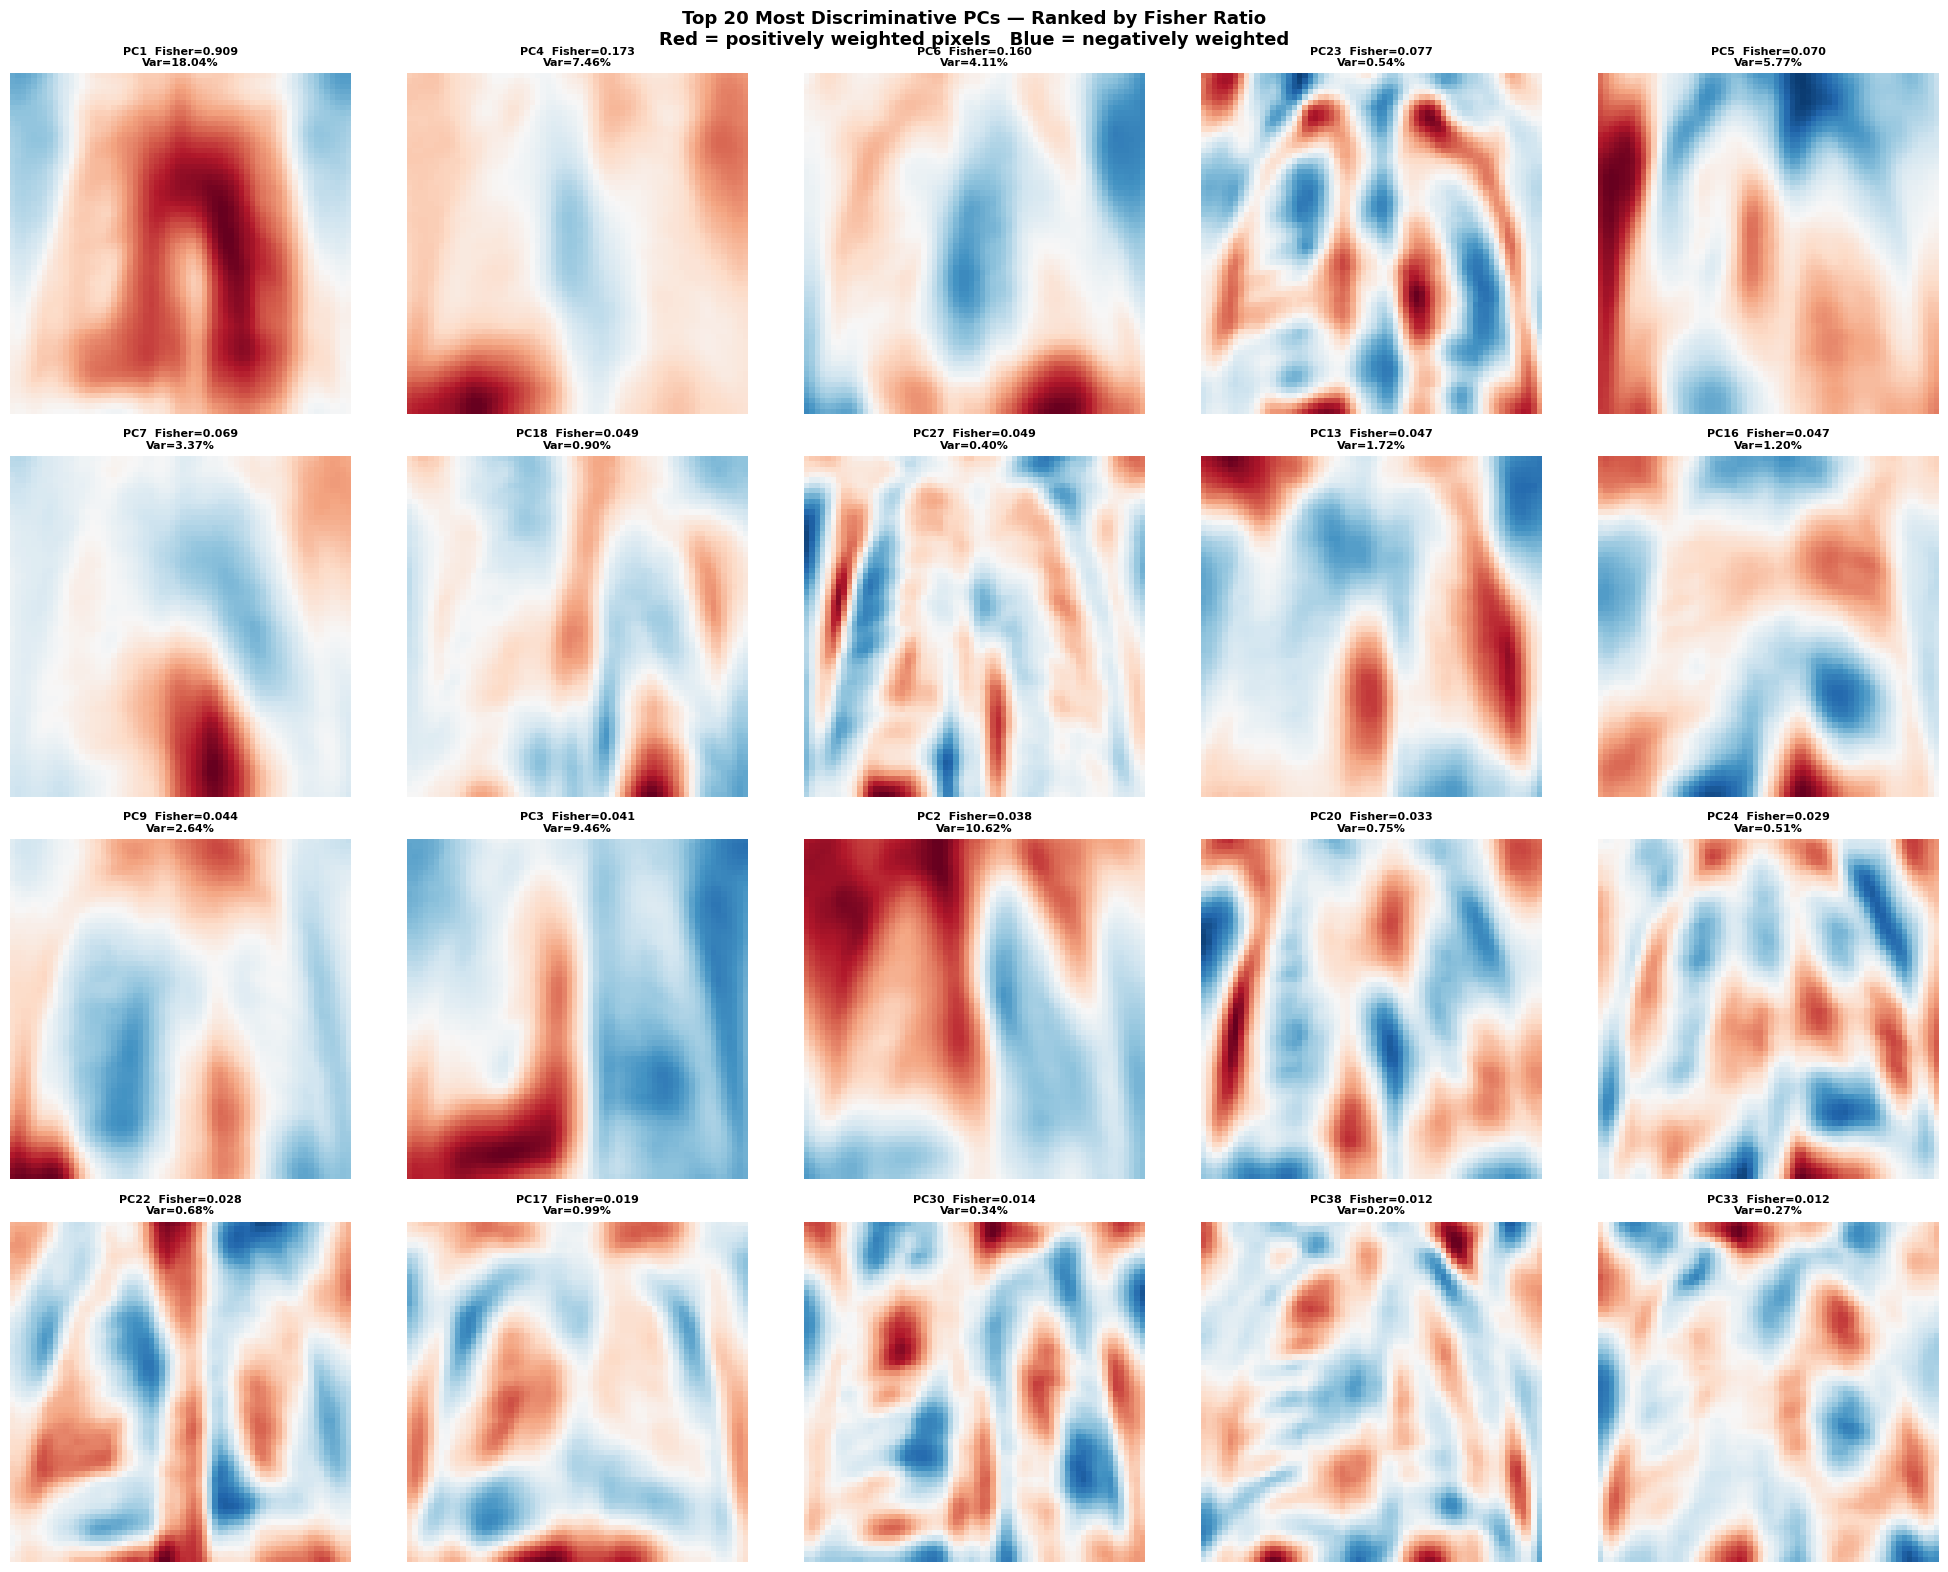

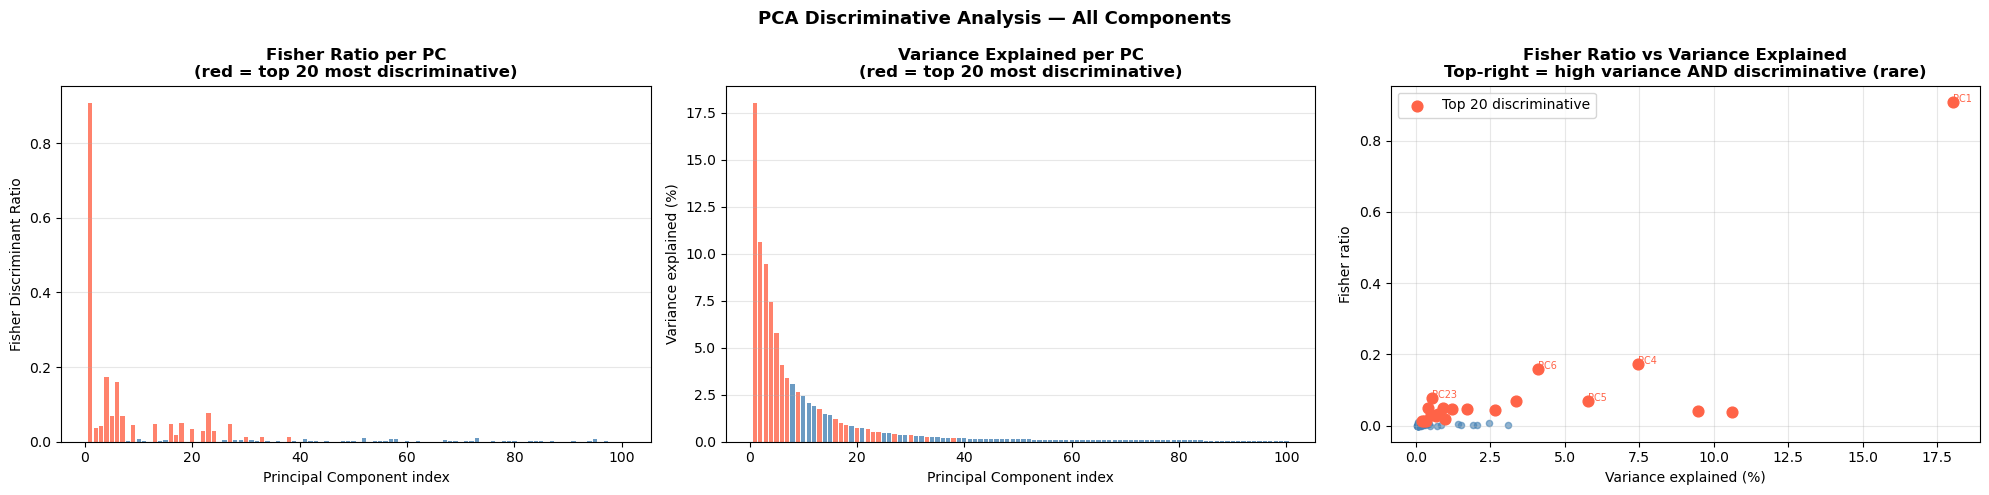

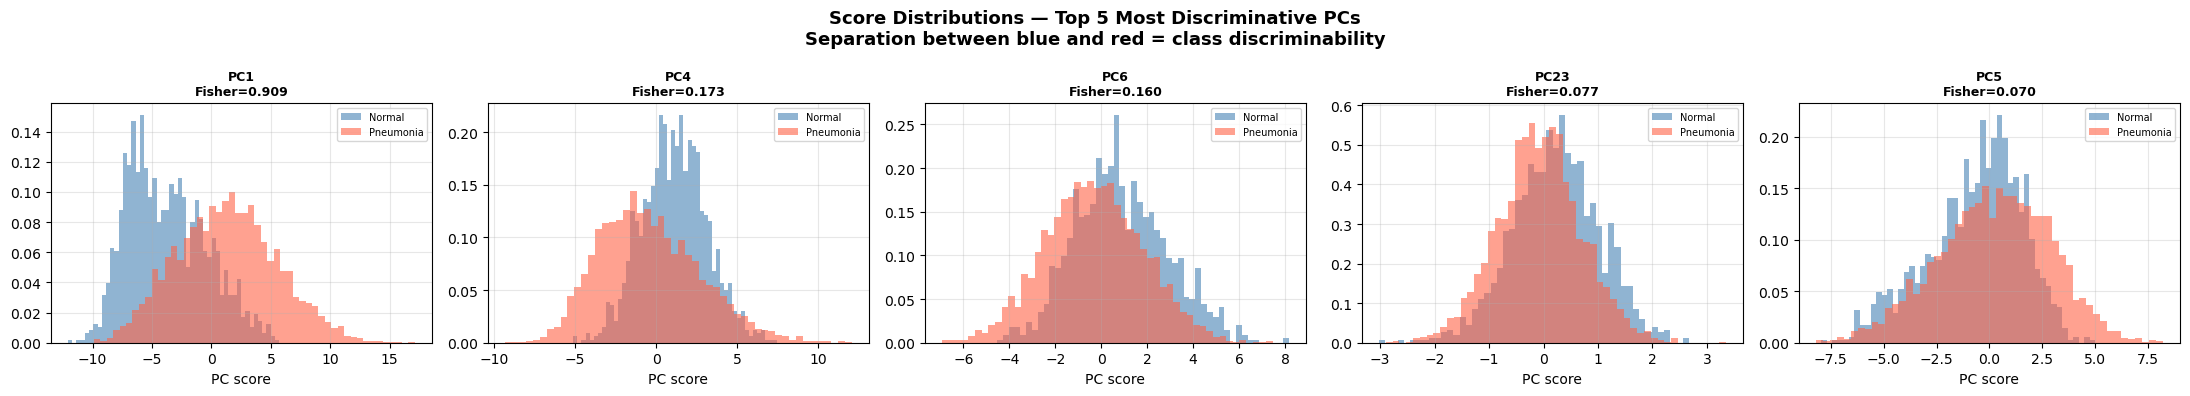

Top 10 most discriminative PCs:
    PC    Fisher    Var %   Cumvar %
--------------------------------------
  PC  1    0.9087   18.039      18.04
  PC  4    0.1726    7.460      45.57
  PC  6    0.1599    4.106      55.45
  PC 23    0.0772    0.543      82.22
  PC  5    0.0700    5.770      51.34
  PC  7    0.0689    3.366      58.82
  PC 18    0.0490    0.897      78.68
  PC 27    0.0488    0.404      84.06
  PC 13    0.0474    1.722      72.68
  PC 16    0.0466    1.204      76.79


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

y_ints         = np.argmax(y_train, axis=1)
X_all          = x_train.reshape(len(x_train), -1).astype(np.float32)
X_normal       = x_train[y_ints == 0].reshape((y_ints==0).sum(), -1)
X_pneumonia    = x_train[y_ints == 1].reshape((y_ints==1).sum(), -1)
DIM            = 64

# Fit PCA with more components
n_components = 100
pca = PCA(n_components=n_components, random_state=42)
pca.fit(X_all)

# Project both classes
proj_normal    = pca.transform(X_normal)    # (N_n, 100)
proj_pneumonia = pca.transform(X_pneumonia) # (N_p, 100)

# Fisher ratio for every PC
fisher = (proj_pneumonia.mean(axis=0) - proj_normal.mean(axis=0))**2 / \
         (proj_pneumonia.std(axis=0)**2 + proj_normal.std(axis=0)**2 + 1e-8)

# ── Plot every PC eigenimage ranked by Fisher ratio ───────────────────────────
top_n   = 20   # show top 20 most discriminative PCs
top_idx = np.argsort(fisher)[::-1][:top_n]

fig, axes = plt.subplots(4, 5, figsize=(20, 16))

for plot_col, pc_idx in enumerate(top_idx):
    row = plot_col // 5
    col = plot_col  % 5

    pc   = pca.components_[pc_idx].reshape(DIM, DIM)
    vmax = np.abs(pc).max()

    axes[row, col].imshow(pc, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[row, col].set_title(
        f'PC{pc_idx+1}  Fisher={fisher[pc_idx]:.3f}\n'
        f'Var={pca.explained_variance_ratio_[pc_idx]*100:.2f}%',
        fontsize=8, fontweight='bold'
    )
    axes[row, col].axis('off')

plt.suptitle('Top 20 Most Discriminative PCs — Ranked by Fisher Ratio\n'
             'Red = positively weighted pixels   Blue = negatively weighted',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_top_discriminative.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot Fisher ratio vs PC index and variance explained ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Fisher ratio per PC
axes[0].bar(range(1, n_components+1), fisher,
            color=['tomato' if i in top_idx else 'steelblue'
                   for i in range(n_components)],
            alpha=0.8)
axes[0].set_xlabel('Principal Component index')
axes[0].set_ylabel('Fisher Discriminant Ratio')
axes[0].set_title('Fisher Ratio per PC\n(red = top 20 most discriminative)',
                   fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Variance explained per PC
axes[1].bar(range(1, n_components+1),
            pca.explained_variance_ratio_ * 100,
            color=['tomato' if i in top_idx else 'steelblue'
                   for i in range(n_components)],
            alpha=0.8)
axes[1].set_xlabel('Principal Component index')
axes[1].set_ylabel('Variance explained (%)')
axes[1].set_title('Variance Explained per PC\n(red = top 20 most discriminative)',
                   fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

# Fisher ratio vs variance explained — scatter
axes[2].scatter(
    pca.explained_variance_ratio_ * 100,
    fisher,
    alpha=0.6, color='steelblue', s=20
)
# Highlight top discriminative PCs
axes[2].scatter(
    pca.explained_variance_ratio_[top_idx] * 100,
    fisher[top_idx],
    color='tomato', s=60, zorder=5, label='Top 20 discriminative'
)
for idx in top_idx[:5]:
    axes[2].annotate(
        f'PC{idx+1}',
        (pca.explained_variance_ratio_[idx]*100, fisher[idx]),
        fontsize=7, color='tomato'
    )
axes[2].set_xlabel('Variance explained (%)')
axes[2].set_ylabel('Fisher ratio')
axes[2].set_title('Fisher Ratio vs Variance Explained\n'
                   'Top-right = high variance AND discriminative (rare)',
                   fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('PCA Discriminative Analysis — All Components',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_all_fisher.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Distribution plots for top 5 most discriminative PCs ─────────────────────
top5 = np.argsort(fisher)[::-1][:5]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for col, idx in enumerate(top5):
    axes[col].hist(proj_normal[:, idx],    bins=50, color='steelblue',
                   alpha=0.6, density=True, label='Normal')
    axes[col].hist(proj_pneumonia[:, idx], bins=50, color='tomato',
                   alpha=0.6, density=True, label='Pneumonia')
    axes[col].set_title(f'PC{idx+1}\nFisher={fisher[idx]:.3f}',
                         fontweight='bold', fontsize=9)
    axes[col].set_xlabel('PC score')
    axes[col].legend(fontsize=7)
    axes[col].grid(alpha=0.3)

plt.suptitle('Score Distributions — Top 5 Most Discriminative PCs\n'
             'Separation between blue and red = class discriminability',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_top5_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print('Top 10 most discriminative PCs:')
print(f'{"PC":>6}  {"Fisher":>8}  {"Var %":>7}  {"Cumvar %":>9}')
print('-' * 38)
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
for idx in np.argsort(fisher)[::-1][:10]:
    print(f'  PC{idx+1:3d}  {fisher[idx]:8.4f}  '
          f'{pca.explained_variance_ratio_[idx]*100:7.3f}  '
          f'{cumvar[idx]:9.2f}')

Top 5 PCs and their weights:
  PC  1 : Fisher=0.9087  weight=0.6545  var=18.04%
  PC  4 : Fisher=0.1726  weight=0.1243  var=7.46%
  PC  6 : Fisher=0.1599  weight=0.1152  var=4.11%
  PC 23 : Fisher=0.0772  weight=0.0556  var=0.54%
  PC  5 : Fisher=0.0700  weight=0.0504  var=5.77%


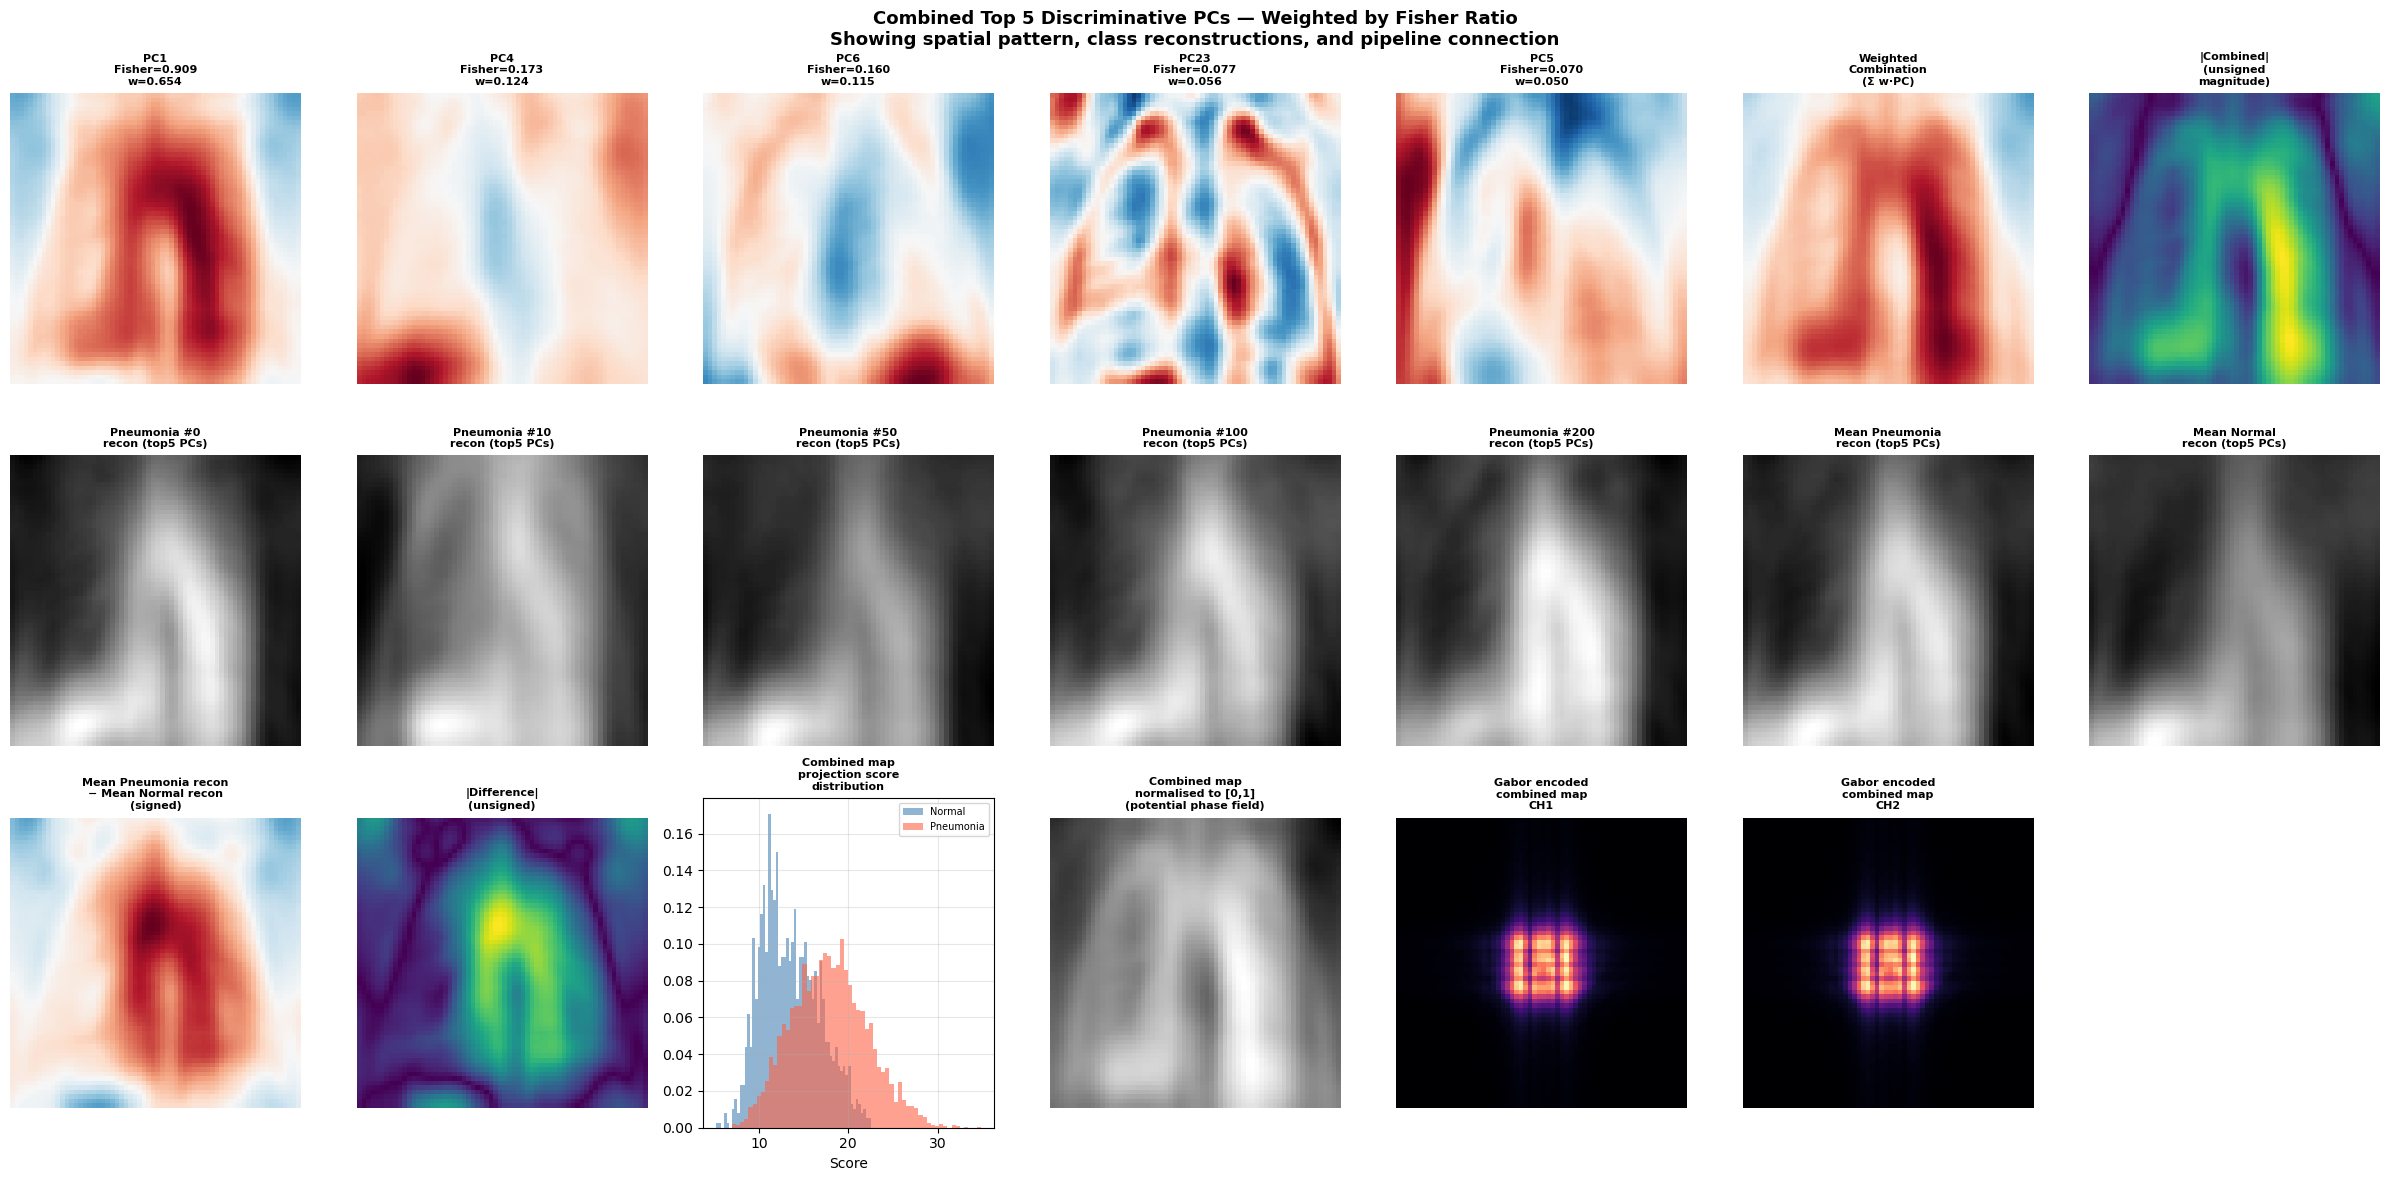


Combined map projection statistics:
  Normal    mean : 13.4811 ± 3.2387
  Pneumonia mean : 17.9264 ± 4.2117
  t-statistic    : -35.2084
  p-value        : 0.000000
  Separation     : significant


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ── Weighted combination of top 5 discriminative PCs ─────────────────────────
top5_idx    = np.argsort(fisher)[::-1][:5]
top5_fisher = fisher[top5_idx]

# Normalise Fisher weights to sum to 1
weights = top5_fisher / top5_fisher.sum()

print('Top 5 PCs and their weights:')
for i, (idx, w) in enumerate(zip(top5_idx, weights)):
    print(f'  PC{idx+1:3d} : Fisher={fisher[idx]:.4f}  weight={w:.4f}  '
          f'var={pca.explained_variance_ratio_[idx]*100:.2f}%')

# ── Build weighted combined map ───────────────────────────────────────────────
combined_map = np.zeros((DIM, DIM), dtype=np.float32)
for idx, w in zip(top5_idx, weights):
    pc = pca.components_[idx].reshape(DIM, DIM).astype(np.float32)
    combined_map += w * pc

# ── Also build mean projection maps per class ─────────────────────────────────
# Project each class onto the top 5 PCs and reconstruct
# This shows what the top 5 discriminative PCs "see" in each class

def reconstruct_from_pcs(X, pca, pc_indices):
    """
    Reconstruct images using only specified PCs.
    Shows what those PCs capture in the data.
    """
    # Project onto selected PCs
    selected_components = pca.components_[pc_indices]   # (k, 4096)
    projections = X @ selected_components.T             # (N, k)

    # Reconstruct
    reconstructed = projections @ selected_components   # (N, 4096)
    reconstructed += pca.mean_                          # add mean back
    return reconstructed.reshape(len(X), DIM, DIM)


recon_normal    = reconstruct_from_pcs(X_normal,    pca, top5_idx)
recon_pneumonia = reconstruct_from_pcs(X_pneumonia, pca, top5_idx)

mean_recon_normal    = recon_normal.mean(axis=0)
mean_recon_pneumonia = recon_pneumonia.mean(axis=0)

# Normalise for display
def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 7, figsize=(24, 12))

# Row 1 — individual top 5 eigenimages + combined map + abs combined
for col, (idx, w) in enumerate(zip(top5_idx, weights)):
    pc   = pca.components_[idx].reshape(DIM, DIM)
    vmax = np.abs(pc).max()
    axes[0, col].imshow(pc, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0, col].set_title(f'PC{idx+1}\nFisher={fisher[idx]:.3f}\nw={w:.3f}',
                            fontsize=8, fontweight='bold')
    axes[0, col].axis('off')

vmax = np.abs(combined_map).max()
axes[0, 5].imshow(combined_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0, 5].set_title('Weighted\nCombination\n(Σ w·PC)',
                      fontsize=8, fontweight='bold')
axes[0, 5].axis('off')

axes[0, 6].imshow(np.abs(combined_map), cmap='viridis')
axes[0, 6].set_title('|Combined|\n(unsigned\nmagnitude)',
                      fontsize=8, fontweight='bold')
axes[0, 6].axis('off')

# Row 2 — what top 5 PCs see in actual images (reconstruction from top5 only)
# Show 5 example pneumonia reconstructions
pneumonia_samples = [0, 10, 50, 100, 200]
for col, idx_img in enumerate(pneumonia_samples):
    axes[1, col].imshow(norm(recon_pneumonia[idx_img]), cmap='gray')
    axes[1, col].set_title(f'Pneumonia #{idx_img}\nrecon (top5 PCs)',
                            fontsize=8, fontweight='bold')
    axes[1, col].axis('off')

axes[1, 5].imshow(norm(mean_recon_pneumonia), cmap='gray')
axes[1, 5].set_title('Mean Pneumonia\nrecon (top5 PCs)',
                      fontsize=8, fontweight='bold')
axes[1, 5].axis('off')

axes[1, 6].imshow(norm(mean_recon_normal), cmap='gray')
axes[1, 6].set_title('Mean Normal\nrecon (top5 PCs)',
                      fontsize=8, fontweight='bold')
axes[1, 6].axis('off')

# Row 3 — difference between pneumonia and normal reconstructions
diff_recon = mean_recon_pneumonia - mean_recon_normal
vmax       = np.abs(diff_recon).max()

axes[2, 0].imshow(diff_recon, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2, 0].set_title('Mean Pneumonia recon\n− Mean Normal recon\n(signed)',
                      fontsize=8, fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].imshow(np.abs(diff_recon), cmap='viridis')
axes[2, 1].set_title('|Difference|\n(unsigned)',
                      fontsize=8, fontweight='bold')
axes[2, 1].axis('off')

# Score distribution for combined map projection
# Project each image onto the combined map direction
combined_flat   = combined_map.flatten()
combined_flat   = combined_flat / (np.linalg.norm(combined_flat) + 1e-8)
score_normal    = X_normal    @ combined_flat
score_pneumonia = X_pneumonia @ combined_flat

axes[2, 2].hist(score_normal,    bins=60, color='steelblue',
                alpha=0.6, density=True, label='Normal')
axes[2, 2].hist(score_pneumonia, bins=60, color='tomato',
                alpha=0.6, density=True, label='Pneumonia')
axes[2, 2].set_title('Combined map\nprojection score\ndistribution',
                      fontsize=8, fontweight='bold')
axes[2, 2].set_xlabel('Score')
axes[2, 2].legend(fontsize=7); axes[2, 2].grid(alpha=0.3)

# Combined map as phase field — what speckle would look like
combined_phase = norm(combined_map)   # normalise to [0,1] for phase field
axes[2, 3].imshow(combined_phase, cmap='gray')
axes[2, 3].set_title('Combined map\nnormalised to [0,1]\n(potential phase field)',
                      fontsize=8, fontweight='bold')
axes[2, 3].axis('off')

# Encode combined map as Gabor speckle
encoded_combined = gabor_THIS(
    combined_phase[np.newaxis], GM1, GM2
)  # (1, 64, 128)

axes[2, 4].imshow(encoded_combined[0, :, :DIM], cmap='magma')
axes[2, 4].set_title('Gabor encoded\ncombined map\nCH1',
                      fontsize=8, fontweight='bold')
axes[2, 4].axis('off')

axes[2, 5].imshow(encoded_combined[0, :, DIM:], cmap='magma')
axes[2, 5].set_title('Gabor encoded\ncombined map\nCH2',
                      fontsize=8, fontweight='bold')
axes[2, 5].axis('off')

axes[2, 6].axis('off')

# Row labels
axes[0, 0].set_ylabel('Top 5 PCs\n+ combined',   fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Class reconstructions\n(top5 PCs only)', fontsize=9, fontweight='bold')
axes[2, 0].set_ylabel('Difference +\npipeline connection', fontsize=9, fontweight='bold')

plt.suptitle('Combined Top 5 Discriminative PCs — Weighted by Fisher Ratio\n'
             'Showing spatial pattern, class reconstructions, and pipeline connection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_combined_top5.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Print separation statistics ───────────────────────────────────────────────
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(score_normal, score_pneumonia)
print(f'\nCombined map projection statistics:')
print(f'  Normal    mean : {score_normal.mean():.4f} ± {score_normal.std():.4f}')
print(f'  Pneumonia mean : {score_pneumonia.mean():.4f} ± {score_pneumonia.std():.4f}')
print(f'  t-statistic    : {t_stat:.4f}')
print(f'  p-value        : {p_val:.6f}')
print(f'  Separation     : {"significant" if p_val < 0.05 else "not significant"}')

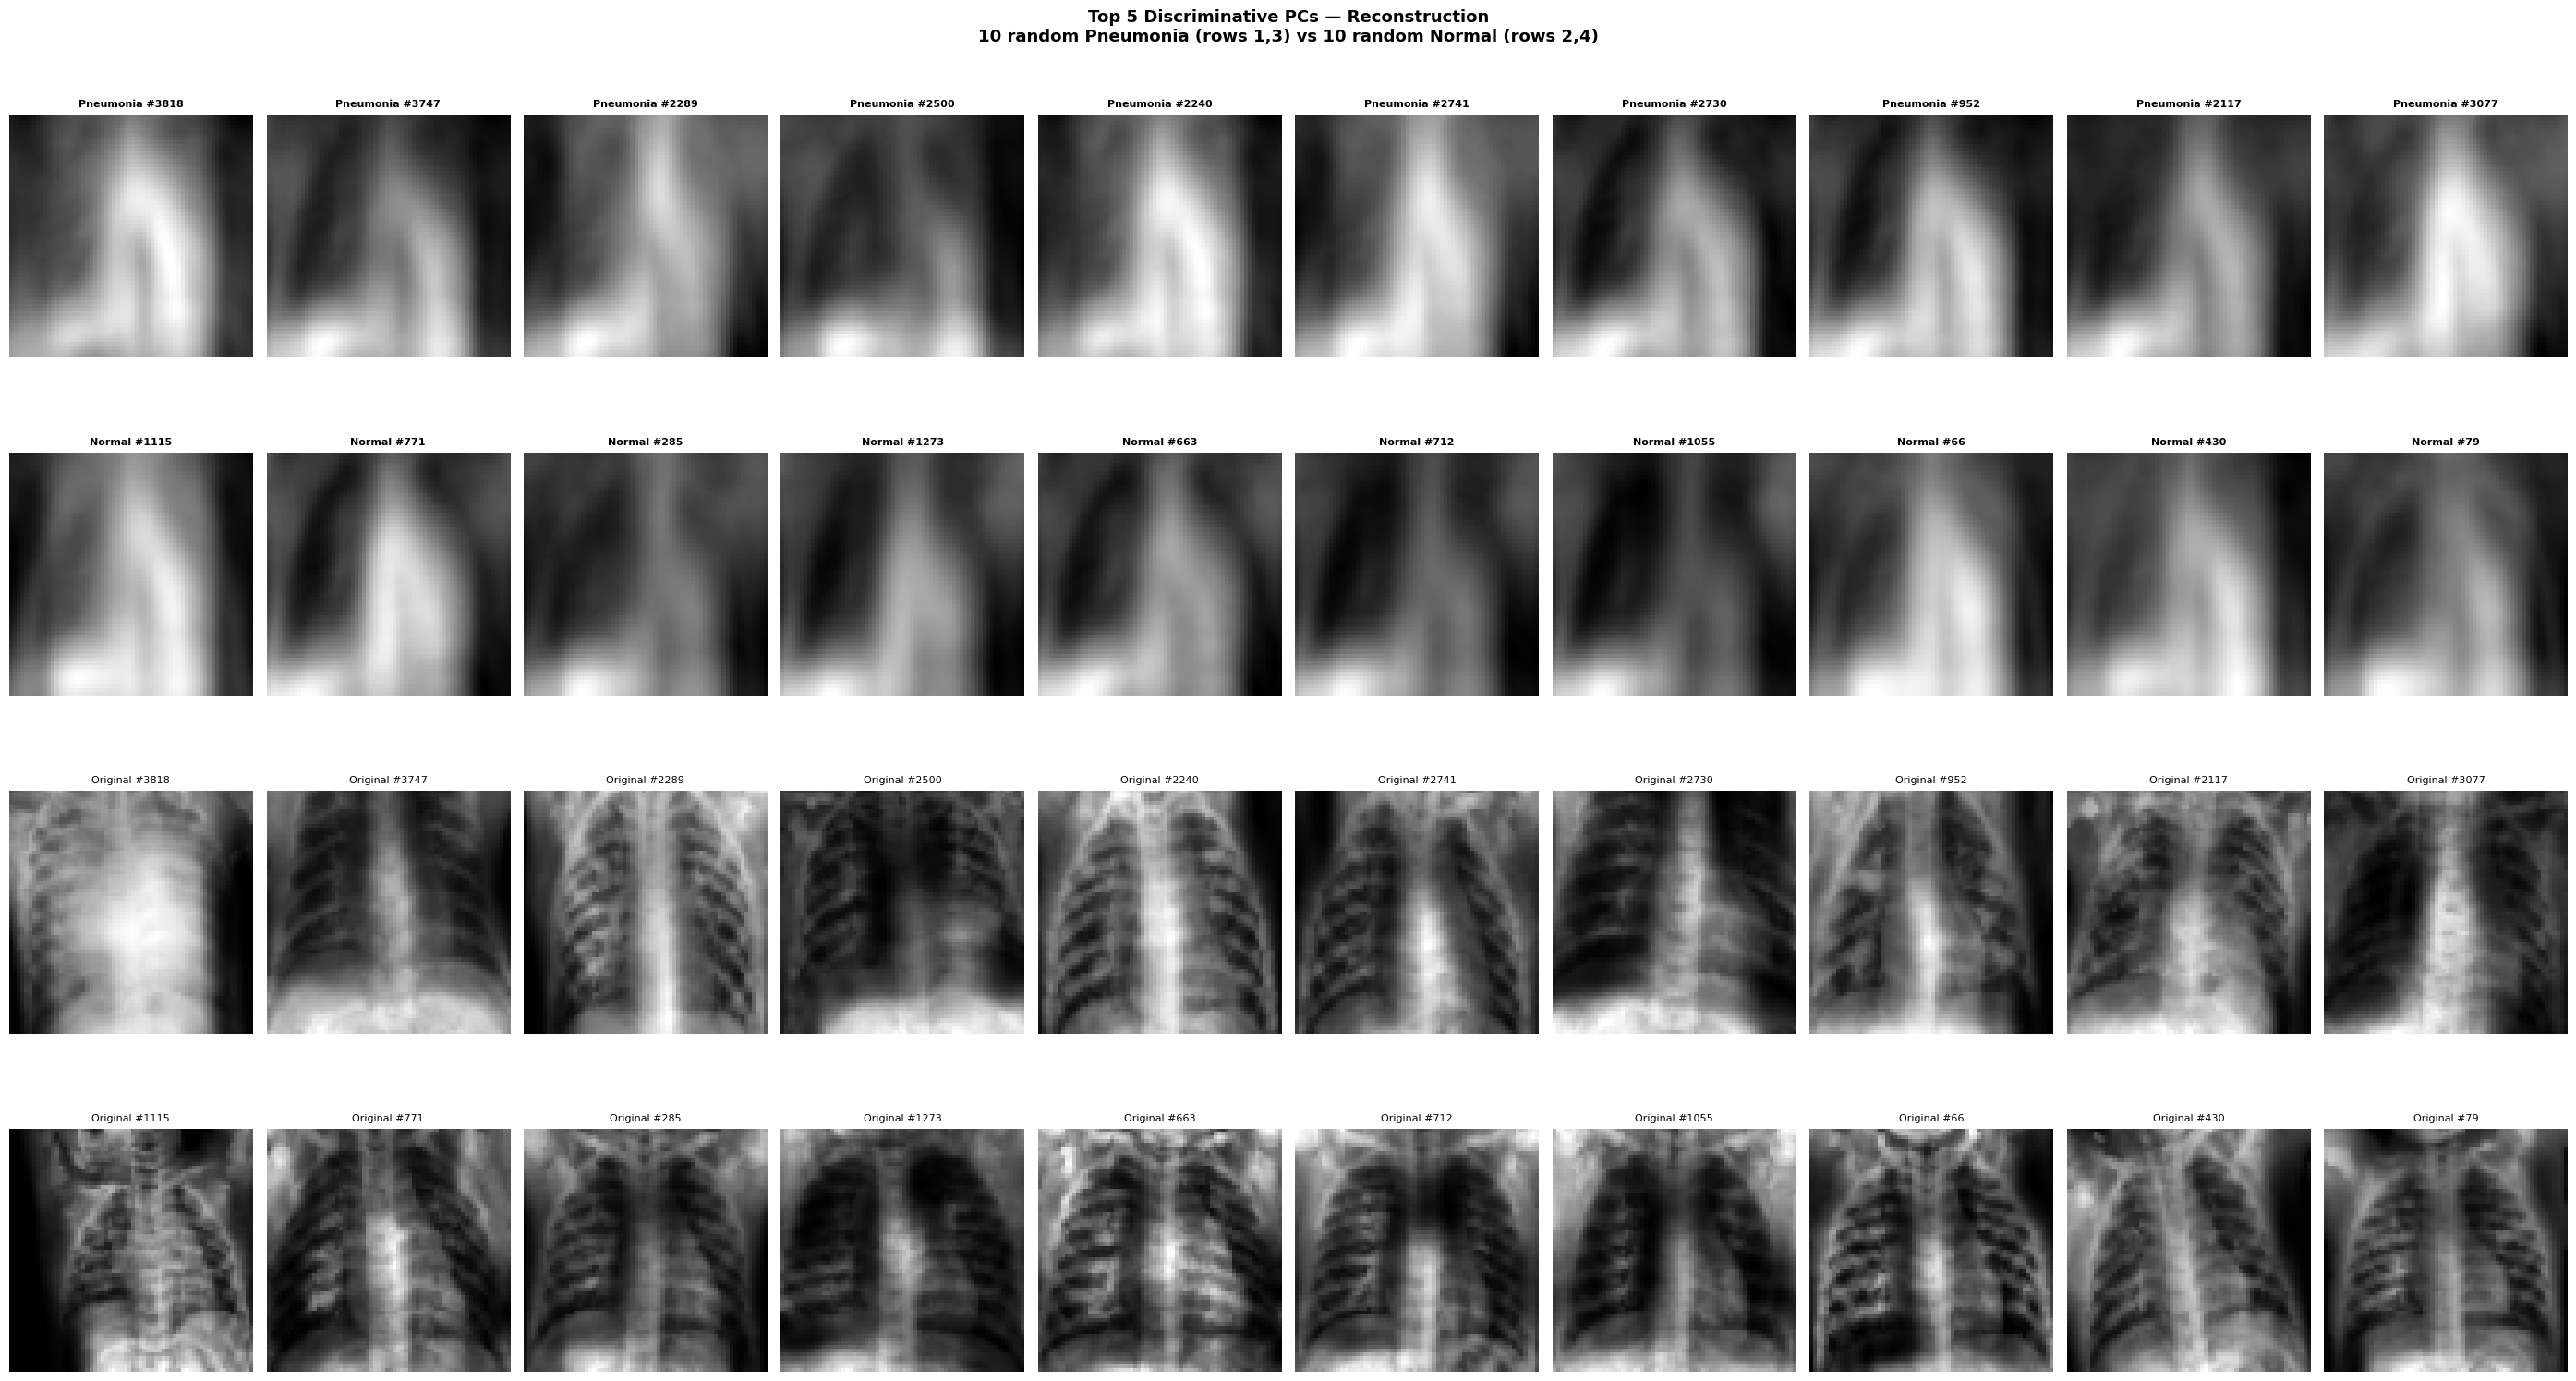

In [12]:
fig, axes = plt.subplots(4, 10, figsize=(28, 16))

# Random sample indices
np.random.seed(42)
pneumonia_sample_idx = np.random.choice(len(recon_pneumonia), 10, replace=False)
normal_sample_idx    = np.random.choice(len(recon_normal),    10, replace=False)

# Row 1 — 10 pneumonia reconstructions (top5 PCs only)
for col, idx_img in enumerate(pneumonia_sample_idx):
    axes[0, col].imshow(norm(recon_pneumonia[idx_img]), cmap='gray')
    axes[0, col].set_title(f'Pneumonia #{idx_img}', fontsize=8, fontweight='bold')
    axes[0, col].axis('off')

# Row 2 — 10 normal reconstructions (top5 PCs only)
for col, idx_img in enumerate(normal_sample_idx):
    axes[1, col].imshow(norm(recon_normal[idx_img]), cmap='gray')
    axes[1, col].set_title(f'Normal #{idx_img}', fontsize=8, fontweight='bold')
    axes[1, col].axis('off')

# Row 3 — original pneumonia images for comparison
for col, idx_img in enumerate(pneumonia_sample_idx):
    axes[2, col].imshow(pneumonia_imgs[idx_img], cmap='gray')
    axes[2, col].set_title(f'Original #{idx_img}', fontsize=8)
    axes[2, col].axis('off')

# Row 4 — original normal images for comparison
for col, idx_img in enumerate(normal_sample_idx):
    axes[3, col].imshow(normal_imgs[idx_img], cmap='gray')
    axes[3, col].set_title(f'Original #{idx_img}', fontsize=8)
    axes[3, col].axis('off')

axes[0, 0].set_ylabel('Pneumonia\nrecon (top5 PCs)', fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Normal\nrecon (top5 PCs)',    fontsize=9, fontweight='bold')
axes[2, 0].set_ylabel('Pneumonia\noriginal',          fontsize=9, fontweight='bold')
axes[3, 0].set_ylabel('Normal\noriginal',             fontsize=9, fontweight='bold')

plt.suptitle('Top 5 Discriminative PCs — Reconstruction\n'
             '10 random Pneumonia (rows 1,3) vs 10 random Normal (rows 2,4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_top5_reconstructions.png', dpi=300, bbox_inches='tight')
plt.show()